# Viz of Evolution data

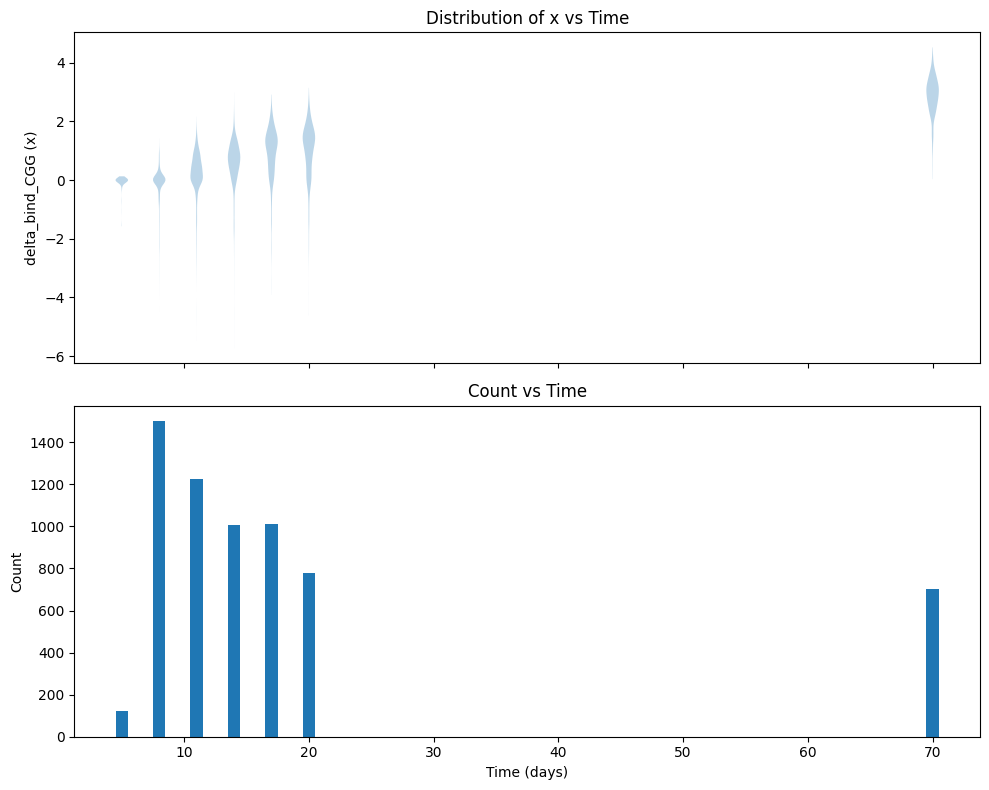

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
data_csv_path = "data.csv"
df = pd.read_csv(data_csv_path, keep_default_na=False)[["time (days)", "mouse", "delta_bind_CGG", "mutations_H", "mutations_L", "n_mutations_H", "n_mutations_L"]]

# Preprocess
df["time (days)"] = df["time (days)"].astype(np.float64)
df.rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}, inplace=True)
assert df.x.isna().sum() == 0

# Group for visualization
count_vs_time = df.groupby("t").size()
# Group for visualization (fixed)
x_vs_time = df.groupby("t")["x"].apply(list)
positions = x_vs_time.index.to_numpy()
data = x_vs_time.tolist()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Distribution of x vs time (violin plot)
axes[0].violinplot(data, positions=positions, widths=1.0, showmeans=False, showmedians=False, showextrema=False)
axes[0].set_ylabel("delta_bind_CGG (x)")
axes[0].set_title("Distribution of x vs Time")

# Count vs time (bar plot)
axes[1].bar(count_vs_time.index, count_vs_time.values, width=1.0)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Time (days)")
axes[1].set_title("Count vs Time")

plt.tight_layout()
plt.show()


# Visualisation of delta G values

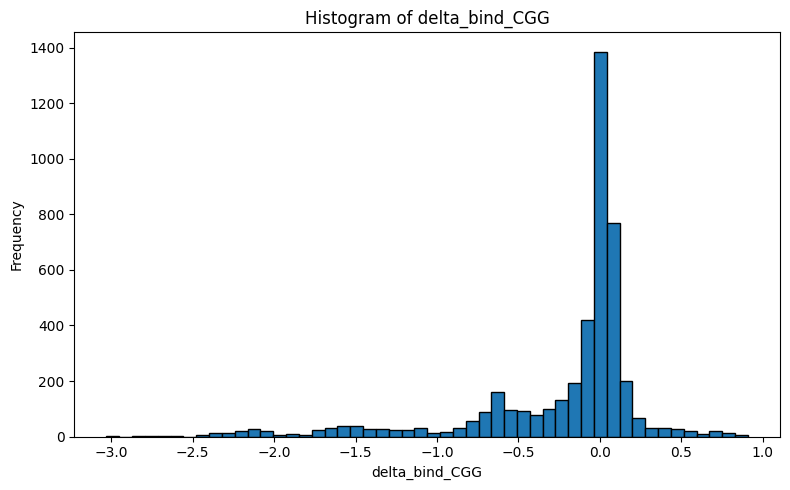

In [8]:
data_csv_path = "final_variant_scores.csv"
df = pd.read_csv(data_csv_path)

# Plot histogram of the 'delta_bind_CGG' column
plt.figure(figsize=(8, 5))
plt.hist(df['delta_bind_CGG'].dropna(), bins=50, edgecolor='black')
plt.xlabel('delta_bind_CGG')
plt.ylabel('Frequency')
plt.title('Histogram of delta_bind_CGG')
plt.tight_layout()
plt.show()


C:\Users\maria\AppData\Local\Temp\ipykernel_39728\799350052.py:18: RuntimeWarning: invalid value encountered in scalar divide
  (1 - p) / (cutoff - x.min()),
C:\Users\maria\AppData\Local\Temp\ipykernel_39728\799350052.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  (1 - p) / (cutoff - x.min()),


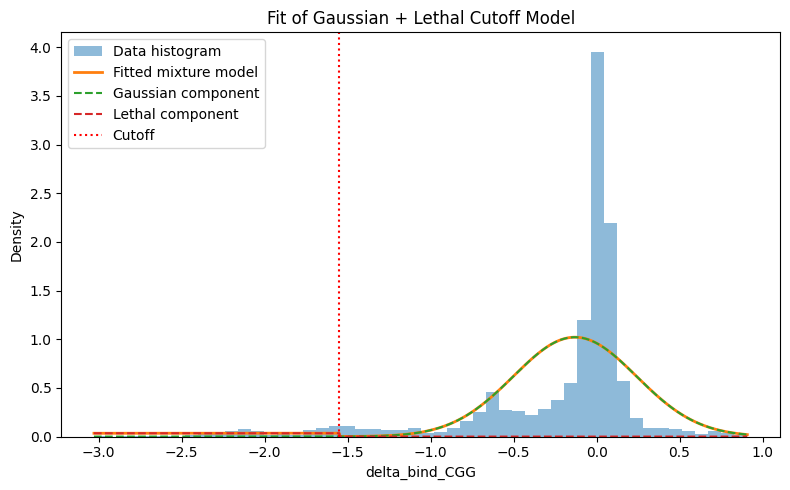

Optimized parameters: mu=-0.13, sigma=0.37, cutoff=-1.55, p=0.95


In [10]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Get the data
x = df['delta_bind_CGG'].dropna().values

# Define the negative log-likelihood of a mixture model: 
# - proportion p of points follow a Gaussian N(mu, sigma)
# - proportion (1 - p) are lethal: values < cutoff
def neg_log_likelihood(params):
    mu, sigma, cutoff, p = params
    if sigma <= 0 or not (0 <= p <= 1):
        return np.inf
    likelihoods = np.where(
        x < cutoff,
        (1 - p) / (cutoff - x.min()),
        p * norm.pdf(x, mu, sigma)
    )
    return -np.sum(np.log(likelihoods + 1e-9))  # add small epsilon to avoid log(0)

# Initial guesses
mu_init = np.mean(x)
sigma_init = np.std(x)
cutoff_init = np.percentile(x, 5)
p_init = 0.8

initial_params = [mu_init, sigma_init, cutoff_init, p_init]

# Minimize the negative log-likelihood
result = minimize(neg_log_likelihood, initial_params, bounds=[
    (-10, 10),  # mu
    (1e-3, 10),  # sigma
    (x.min(), x.max()),  # cutoff
    (0, 1)  # p
])

# Extract optimized parameters
mu_opt, sigma_opt, cutoff_opt, p_opt = result.x

# Plot the fitted mixture model with histogram
x_vals = np.linspace(x.min(), x.max(), 1000)
gaussian_pdf = p_opt * norm.pdf(x_vals, mu_opt, sigma_opt)
lethal_mask = x_vals < cutoff_opt
lethal_pdf = (1 - p_opt) / (cutoff_opt - x.min()) * lethal_mask

plt.figure(figsize=(8, 5))
plt.hist(x, bins=50, density=True, alpha=0.5, label='Data histogram')
plt.plot(x_vals, gaussian_pdf + lethal_pdf, label='Fitted mixture model', linewidth=2)
plt.plot(x_vals, gaussian_pdf, '--', label='Gaussian component', linewidth=1.5)
plt.plot(x_vals, lethal_pdf, '--', label='Lethal component', linewidth=1.5)
plt.axvline(cutoff_opt, color='red', linestyle=':', label='Cutoff')
plt.xlabel('delta_bind_CGG')
plt.ylabel('Density')
plt.title('Fit of Gaussian + Lethal Cutoff Model')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Optimized parameters: mu={mu_opt:.2f}, sigma={sigma_opt:.2f}, cutoff={cutoff_opt:.2f}, p={p_opt:.2f}")
